# Task 1: Load the dataset into a DataFrame

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Lab6.csv')

# Task 2: Explore the data (head, info, describe)

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


# Task 3: Perform basic data cleaning

In [ ]:
df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

No missing values, great for Linear regression. 

Accourding to task 2's output we can say that the dataset is made of numerical values, also great for linear regression. 

In [ ]:
from sklearn.preprocessing import StandardScaler
df = df.drop(columns=["Address"]) #Dropped because it contains textual values. 
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df))

In [ ]:
df['Area Population'] = np.log1p(df['Area Population'])
df['Avg. Area House Age'] = np.log1p(df['Avg. Area House Age'])
df['Avg. Area Income'] = np.log1p(df['Avg. Area Income'])
df['Avg. Area Number of Bedrooms'] = np.log1p(df['Avg. Area Number of Bedrooms'])
df['Income'] = np.log1p(df['Income'])
df['Price'] = np.log1p(df['Price'])

Detected and handled outliers using "Log transform skewed variables"

In [19]:
df = df.drop_duplicates()

Handled duplicated data entries.

# Task 4: Apply feature engineering (if applicable) 

In [20]:
df["Rooms_per_Bedrooms"] = df['Avg. Area Number of Rooms'] / df['Avg. Area Number of Bedrooms']
#A column for the relationship that describes the connection between a room area and a bedroom area.

df['Income_for_Age'] = df['Avg. Area Income'] * df['Avg. Area House Age']
#A coulmn for the relationship between the income of the owners and the house's age. 

# Task 5: Prepare the data for modeling

In [28]:
df.head() #To take a look at the dataset after feature engineering and cleaning. 

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Income,Rooms_per_Bedrooms,Income_for_Age
0,11.284097,1.899546,7.009188,1.627278,10.047060,13.872868,2.508305,4.307309,21.434663
1,11.280358,1.946324,6.730821,1.408545,10.600977,14.224896,2.508001,4.778563,21.955235
2,11.023340,1.926566,8.512727,1.813195,10.515510,13.872825,2.486850,4.694878,21.237189
3,11.056371,2.102699,5.586729,1.449269,10.443228,14.047112,2.489593,3.854859,23.248214
4,11.001820,1.798496,7.839388,1.654411,10.179417,13.354973,2.485058,4.738476,19.786727


In [32]:
#Features:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 
        'Area Population', 'Income', 'Rooms_per_Bedrooms', 'Income_for_Age']]
#Target Variable: 
y= df['Price']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, 
                                                    random_state= 42)

# Task 6: Train the model

In [35]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

lm.fit(X_train, y_train)

LinearRegression()

# Task 7: Evaluate the model performance

In [37]:
print(lm.intercept_)

-41.73866167319052


In [40]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns= ['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,4.428933
Avg. Area House Age,18.696667
Avg. Area Number of Rooms,0.071665
Avg. Area Number of Bedrooms,0.182297
Area Population,0.446314
Income,-0.502798
Rooms_per_Bedrooms,0.057966
Income_for_Age,-1.588312


In [42]:
Predictions = lm.predict(X_test)

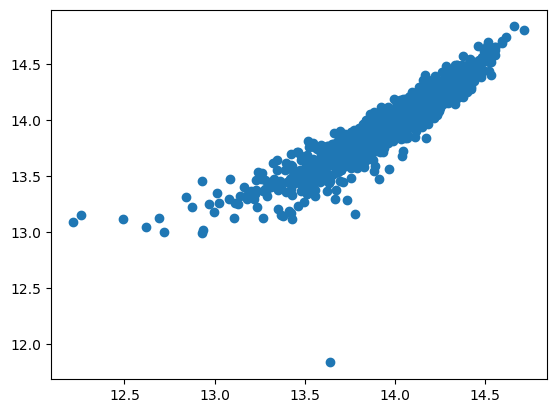

In [43]:
plt.scatter(y_test, Predictions)

The datapoins are almost in a straight line. Indicating good enough performance. 

C:\Users\Aleen\AppData\Local\Temp\ipykernel_26212\445099331.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-Predictions), bins= 50);


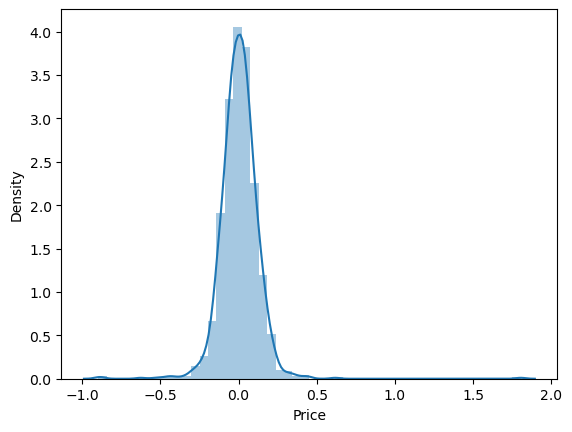

In [46]:
sns.distplot((y_test-Predictions), bins= 50);

I is just a bit skewed right. 

In [49]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, Predictions))
print('MSE:', metrics.mean_squared_error(y_test, Predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, Predictions)))

MAE: 0.08428348110673044
MSE: 0.01572806563808578
RMSE: 0.12541158494367968
